In [2]:
import numpy as np
import scipy
from scipy.optimize import curve_fit
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import pickle
plt = sns.mpl.pyplot
from scipy.optimize import fmin_l_bfgs_b


import h5py as h5

import json

# plotting the spec signal data at different temperatures:
import numpy as np
import scipy
from scipy import special

import sys

import ctypes

import time

import datetime

import threading

import healpy as hp

import numpy as np
import matplotlib.pyplot as plt
import torch
#!pip install torch pyro-ppl matplotlib numpy
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

import pyro.distributions.transforms as T

from pyro.infer.autoguide.initialization import init_to_value

from numpy.random import multivariate_normal




#!/usr/bin/env python

import numpy as np
import scipy
from scipy.optimize import curve_fit
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import healpy as hp

import pickle
plt = sns.mpl.pyplot
from scipy.optimize import fmin_l_bfgs_b

import h5py as h5
import h5py

import json

# plotting the spec signal data at different temperatures:
import numpy as np
import scipy
from scipy import special

import sys

import time




import h5py
import os, sys


/home/ecp/virtual_environment/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
hem = '35'

batch = 'batch2'

name = 'Self_Monitoring_data_25C'


f = h5py.File(f"/home/ecp/disk1/pocam_data/{batch}/prod_characterization_{hem}/{name}.h5")

In [4]:
print(f.keys())

print(f['metadata/'].keys())

print(f['metadata/sipm_pwm'][()])

<KeysViewHDF5 ['breakdown', 'flashes', 'metadata', 'mode_settings', 'thresholds']>
<KeysViewHDF5 ['ab_sn', 'coarse-fine', 'db_sn', 'flasher_modes', 'flasher_pwm', 'ib_sn', 'kapu_mode', 'mmb_sn', 'n_trigs', 'on_board_PD_sn', 'shadow_mount_sn', 'sipm_pwm', 'target', 'temperature', 'time', 'trig_per']>
[52049 53049 55549]


In [5]:
#if necessary adjust the path from where to load stuff, but they should mostly live in the same dir:
sys.path.append("/home/ecp/self_monitoring_scripts/")

from POCAMSiPMHandler import breakdown_func, baseline, ampl

from pcm_monitoring_func import decode_value, get_timestamps, getADCreadings, extract_per_pwm, convert_to_perTrig, get_SiPM_dt


In [6]:
hem = '50'

batch = 'batch2'

name = 'Self_Monitoring_data_25C'


f_ = h5py.File(f"/home/ecp/disk1/pocam_data/{batch}/prod_characterization_{hem}/{name}.h5")

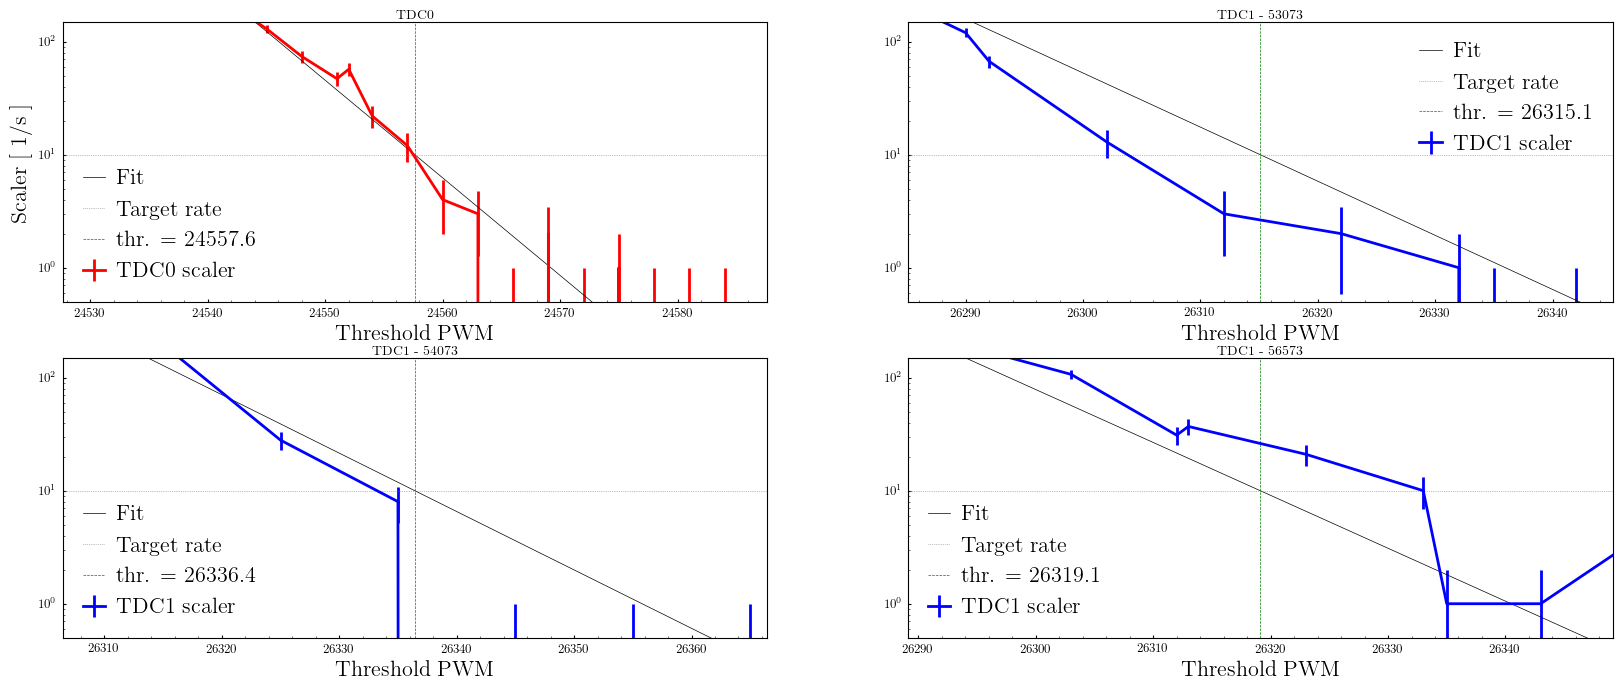

In [34]:
thresholds = {}



fig = plt.figure(figsize=(20,8), facecolor="w")


plt_cntr = 0

sipm_pwm_index = -1


for key_ in f_['thresholds'].keys():

    i_ = int(key_.split('_')[0][3])


    ax = fig.add_subplot(2,2,plt_cntr+1)
    plt_cntr += 1


    xvals_ = np.array( [int(b.decode('utf-8')) for b in f_['thresholds'][key_]['all_thresholds'][()]] )
    yvals_ = np.array( [int(b.decode('utf-8')) for b in f_['thresholds'][key_]['all_scalers'][()]] )


    yerr_ = np.sqrt(yvals_)
    yerr_[yvals_==0] = 1.0

    if i_ == 0:
        c_ = 'red'
    else:
        c_ = 'blue'
        sipm_pwm_index += 1

    ax.errorbar(xvals_, yvals_,yerr=yerr_, marker="o", ms=2, lw=2, 
                label = f"TDC{i_} scaler", color=c_)


    target_rate = float(f_['thresholds'][key_]['target_rate'][()].decode('utf-8')) 
    thr_fit = np.array( [float(b.decode('utf-8')) for b in f_['thresholds'][key_]['fit_result'][()]] )


    ax.set_xlim(thr_fit[0]-30, thr_fit[0]+30)
    xplot = np.linspace(thr_fit[0]-30, thr_fit[0]+30, 100)
    ax.plot(xplot, target_rate*np.exp( -thr_fit[1] * (xplot - thr_fit[0] )), color="k", label="Fit")
    ax.axhline(target_rate, color="0.5", ls=":", label = "Target rate")
    ax.axvline(thr_fit[0], color="g", ls="--",label ="thr. = {:0.1f}".format(thr_fit[0]))
    ax.legend(fontsize=16)
    ax.set_yscale("log")
    ax.set_ylim(0.5,150)
    if i_==0:
        ax.set_ylabel("Scaler [ 1/s ]", fontsize=16)
    ax.set_xlabel("Threshold PWM", fontsize=16)
    if i_ == 0:
        ax.set_title(f"TDC{i_}")
        thresholds[f"TDC{i_}"] = "{:0.1f}".format(thr_fit[0])
    else:
        ax.set_title(f"TDC{i_} - {f_['metadata']['sipm_pwm'][sipm_pwm_index]}")
        thresholds[f"TDC{i_} - {f_['metadata']['sipm_pwm'][sipm_pwm_index]}"] = "{:0.1f}".format(thr_fit[0])
        
#plt.savefig(f"/home/ecp/test_folder/MA/threshold_checks/threshold_hem_{hem}_{temp}C.png", dpi=300)

In [35]:
thresholds

{'TDC0': '24557.6',
 'TDC1 - 53073': '26315.1',
 'TDC1 - 54073': '26336.4',
 'TDC1 - 56573': '26319.1'}

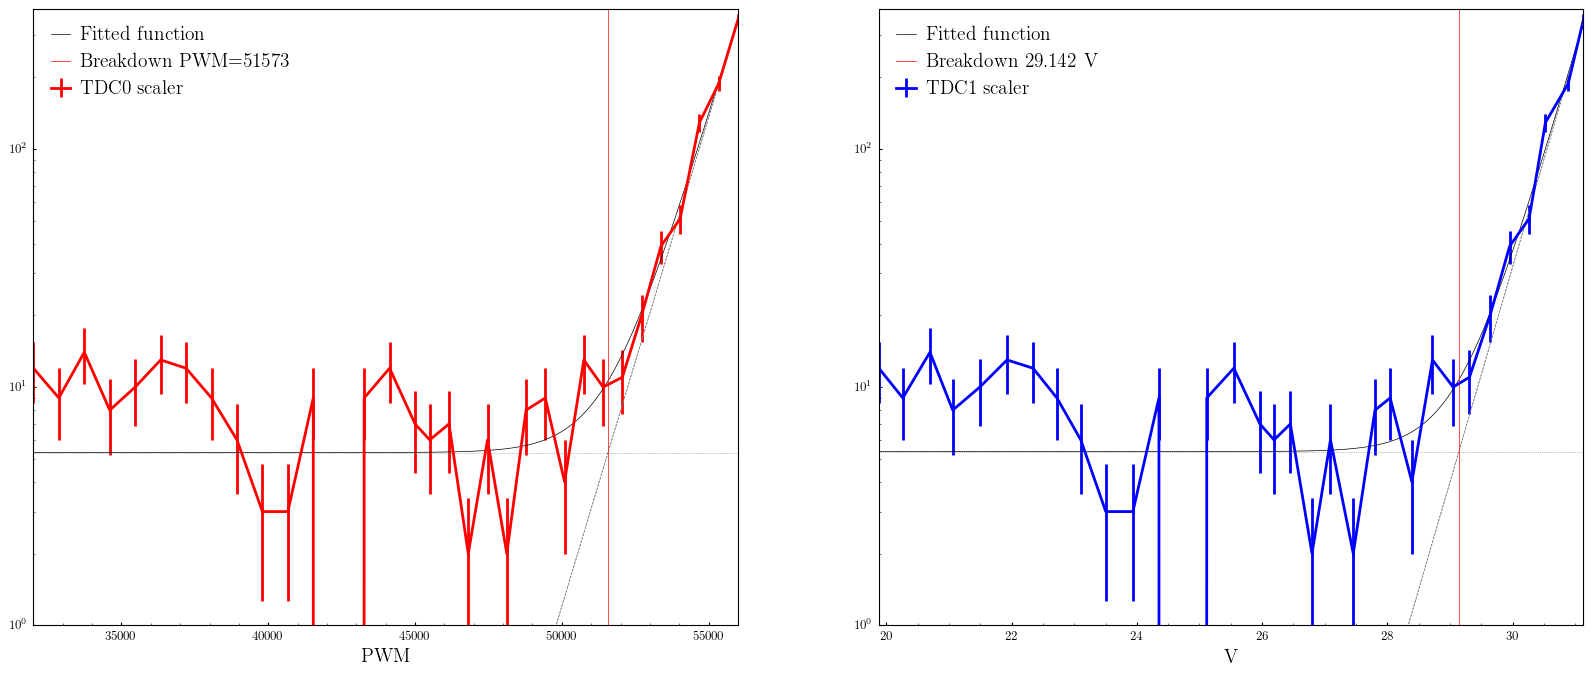

In [40]:
breakdown = {}


fig = plt.figure(figsize=(20,8), facecolor="w")

for i_ in [0,1]:
    ax = fig.add_subplot(1,2,i_+1)

    if i_ ==0: 
        var_ ='pwm'
    elif i_ == 1 : 
        var_ ='V'

    xvals_= np.array( [float(b.decode('utf-8')) for b in f_['breakdown'][f'sipm_{var_}'][()]] )

    if var_ == 'V': 
        xvals_=-1*xvals_

    fit_vals_ =  np.array( [float(b.decode('utf-8')) for b in f_['breakdown'][f'fit_{var_}'][()]] )

    xplot_ = np.linspace(xvals_[0], xvals_[-1], 200)
    bd_val_ = float( f_['breakdown'][f'breakdown_{var_}'][()].decode('utf-8') )
    yvals_ = np.array( [float(b.decode('utf-8')) for b in  f_['breakdown']['scalers'][()]] )

    ###
    yerr_=np.sqrt(yvals_)
    yerr_[yvals_==0] = 1.0

    if i_ == 0:
        c_ = 'red'
    else:
        c_ = 'blue'

    ax.errorbar(xvals_, yvals_,yerr=yerr_, marker="o", ms=2, lw=2, 
            label = f"TDC{i_} scaler", color=c_) 

    #print()

    ax.plot(xplot_, breakdown_func(xplot_, *fit_vals_), color="k", label = "Fitted function")
    ax.plot(xplot_, baseline(xplot_, fit_vals_[0], fit_vals_[1]), color="0.5", ls =":")
    ax.plot(xplot_, ampl(xplot_, fit_vals_[2], fit_vals_[3]), color="0.5", ls ="--")
    ax.plot(xplot_, ampl(xplot_, fit_vals_[2], fit_vals_[3]), color="0.5", ls ="--")
    label_ = "Breakdown "
    if var_ == 'pwm':
        label_+= "PWM={:d}".format(int(np.round(bd_val_)))
        breakdown["SiPM PWM"] = "{:d}".format(int(np.round(bd_val_)))
    elif var_ == "V":
        label_+= "{:0.3f} V".format(bd_val_)
        breakdown["SiPM Voltage [V]"] = "{:0.3f}".format(bd_val_)
    ax.axvline(bd_val_, color="r", label = label_)
    ax.legend(fontsize=14)
    ax.set_ylim(1)
    ax.set_xlim(xplot_[0], xplot_[-1])
    ax.set_yscale("log")
    ax.set_xlabel(var_.upper(), fontsize=14)

#plt.savefig(f"/home/ecp/test_folder/MA/threshold_checks/breakdown_hem_{hem}_{temp}C.png", dpi=300)

In [41]:
breakdown

{'SiPM PWM': '51573', 'SiPM Voltage [V]': '29.142'}

In [8]:
all_data = {}
for sipm_pwm_ in f_['metadata']['sipm_pwm']:
    all_data[sipm_pwm_]= {}
    for flm_ in f_['metadata']['flasher_modes']:
        all_data[sipm_pwm_][flm_.decode()] = extract_per_pwm(f_['flashes/{:d}/{:s}'.format(sipm_pwm_, flm_.decode())])

In [26]:
data_dict = {}


for flasher in ['lmg0', 'lmg1', 'lmg2', 'lmg3', 'kapu0', 'kapu3']:
    ### 'lmg0', 'lmg1', 'lmg2', 'lmg3', 'kapu0', 'kapu3'
    
    
    data_dict[flasher] = {}
    data_dict[flasher]["sipm_data"] = {}
    data_dict[flasher]["pd_data"] = {}
    
    
    lmg1_app = '_A'
        
    # 'lmg0', 'lmg1_A', 'lmg1_B', 'lmg2', 'lmg3', 'kapu0', 'kapu3'
    #flm_=flm_.decode()
    fig = plt.figure(figsize=(10,7), facecolor="w")
    ax = fig.add_axes([0.08,0.08,0.88,0.88])
    ####
    
    for sipm_pwm_ in f_['metadata']['sipm_pwm'][()]:#[:2]: 
        
        
        data_dict[flasher]["sipm_data"][str(sipm_pwm_)] = {}
        
"""
        if not 'lmg1' in flasher:
        #if flasher != 'lmg1':
            ax.plot(
                f_['metadata']['flasher_pwm'][()],
                [all_data[sipm_pwm_][flasher][fpwm_]['tdc1_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()]] ,
                color="red",
            )
            ax.scatter(
                f_['metadata']['flasher_pwm'][()],
                [all_data[sipm_pwm_][flasher][fpwm_]['tdc1_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()]] ,
                color="red",
                label='tdc1_dt vs flasher-pwm'
            )
            
            
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc1'] = {}
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc1']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc1']['tdc1_dt_mean'] = [all_data[sipm_pwm_][flasher][fpwm_]['tdc1_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()]]
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc1']['tdc1_dt_std'] = [all_data[sipm_pwm_][flasher][fpwm_]['tdc1_dt'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()]]
            
            
            
            ax.plot(
                f_['metadata']['flasher_pwm'][()],
                [all_data[sipm_pwm_][flasher][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] ,
                color="orange",
            )
            ax.scatter(
                f_['metadata']['flasher_pwm'][()],
                [all_data[sipm_pwm_][flasher][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] ,
                color="orange",
                label='tdc2_dt vs flasher-pwm'
            )

            
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc2'] = {}
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc2']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc2']['tdc2_dt_mean'] = [all_data[sipm_pwm_][flasher][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()]]
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc2']['tdc2_dt_std'] = [all_data[sipm_pwm_][flasher][fpwm_]['tdc2_dt'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()]]
            
        
        
        
        
        # the following are meant to plot the same thing as above but for data of using SiPM in different mode
        # for flasher 365nm flasher (lmg1_A, lmg1_B), else it just would add renundant plotting:
        elif 'lmg1' in flasher:
        #elif flasher == 'lmg1':
            #if '_A' in flasher:
            ax.plot(
                f_['metadata']['flasher_pwm'][()],
                [all_data[sipm_pwm_]['lmg1' + lmg1_app][fpwm_]['tdc1_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] ,
                color="red",
            )
            ax.scatter(
                f_['metadata']['flasher_pwm'][()],
                [all_data[sipm_pwm_]['lmg1' + lmg1_app][fpwm_]['tdc1_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] ,
                color="red",
            )
            
            
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc1'] = {}
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc1']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc1']['tdc1_dt_mean'] = [all_data[sipm_pwm_]['lmg1' + lmg1_app][fpwm_]['tdc1_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ]
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc1']['tdc1_dt_std'] = [all_data[sipm_pwm_]['lmg1' + lmg1_app][fpwm_]['tdc1_dt'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ]
            



            ax.plot(
                f_['metadata']['flasher_pwm'][()],
                [all_data[sipm_pwm_]['lmg1' + lmg1_app][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] ,
                color="orange",
            )
            ax.scatter(
                f_['metadata']['flasher_pwm'][()],
                [all_data[sipm_pwm_]['lmg1' + lmg1_app][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] ,
                color="orange",
            )
            
            
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc2'] = {}
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc2']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc2']['tdc1_dt_mean'] = [all_data[sipm_pwm_]['lmg1' + lmg1_app][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ]
            data_dict[flasher]["sipm_data"][str(sipm_pwm_)]['tdc2']['tdc1_dt_std'] = [all_data[sipm_pwm_]['lmg1' + lmg1_app][fpwm_]['tdc2_dt'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ]
            


            elif '_B' in flasher:
                ax.plot(
                    f_['metadata']['flasher_pwm'][()],
                    [all_data[sipm_pwm_]['lmg1' + '_B'][fpwm_]['tdc1_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] ,
                    color="yellow",
                )
                ax.scatter(
                    f_['metadata']['flasher_pwm'][()],
                    [all_data[sipm_pwm_]['lmg1' + '_B'][fpwm_]['tdc1_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] ,
                    color="yellow",
                )



                ax.plot(
                    f_['metadata']['flasher_pwm'][()],
                    [all_data[sipm_pwm_]['lmg1' + '_B'][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] ,
                    color="green",
                )
                ax.scatter(
                    f_['metadata']['flasher_pwm'][()],
                    [all_data[sipm_pwm_]['lmg1' + '_B'][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] ,
                    color="green",
                )
                #-all_data[sipm_pwm_][flasher + '_B'][0]['tdc2_dt'][0] + 
"""
        
        
        
        
        if not 'lmg1' in flasher:
            flasher_pd = flasher
        elif 'lmg1' in flasher:
            flasher_pd = flasher + lmg1_app#flasher_pd
        
        
        plotval = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcA']['sum'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        #print(plotval)
        #print(flasher)
        try:
            pass
            #plotval = plotval - all_data[sipm_pwm_][flasher_pd][0]['adcA']['peak'].mean()
            #print(all_data[sipm_pwm_][flasher_pd][0]['adcA']['peak'].mean(),'\n\n')
            #plotval = plotval/np.max(plotval)
        except:
            print('no flasher pwm 0')
        
        ax.plot(
            f_['metadata']['flasher_pwm'][()],
            plotval/10**5,
            color="purple",
        )
        plt.scatter(
            f_['metadata']['flasher_pwm'][()],
            plotval/10**5,
            color="purple",
            label='adcA vs flasher-pwm'
        )
        
        
        data_dict[flasher]["pd_data"]['adcA'] = {}
        data_dict[flasher]["pd_data"]['adcA']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["pd_data"]['adcA']['adcA_peak_mean'] = 10*plotval
        data_dict[flasher]["pd_data"]['adcA']['adcA_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcA']['peak'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        
        
        
        
        
        plotval = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcB']['sum'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        try:
            pass
            #plotval = plotval - all_data[sipm_pwm_][flasher_pd][0]['adcB']['peak'].mean()
            #plotval = plotval/np.max(plotval)
        except:
            print('no flasher pwm 0')
        
        ax.plot(
            f_['metadata']['flasher_pwm'][()],
            plotval/10**5,
            color="blue",
        )
        
        ax.scatter(
            f_['metadata']['flasher_pwm'][()],
            plotval/10**5,
            color="blue",
            label='adcB vs flasher-pwm'
        )
        
        #print(plotval)
        
        data_dict[flasher]["pd_data"]['adcB'] = {}
        data_dict[flasher]["pd_data"]['adcB']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["pd_data"]['adcB']['adcB_peak_mean'] = 10*plotval
        data_dict[flasher]["pd_data"]['adcB']['adcB_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcB']['peak'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        
        
    
    ax.set_title(flasher.upper(), fontsize=16)
    
    #ax.set_ylim(-1, 10)
    
    ax.set_xlabel("Emitter PWM [a.u.]", fontsize=18)
    
    ax.set_ylabel("Self-Monitoring Signals [a.u.]", fontsize=18)
    
    ax.grid('both')

    
    #ax.legend(loc='best')
    
    
    #fig.savefig('/home/ecp/test_folder/MA/self_monitoring_Colloquium_lmg0.png', dpi=300)
    
    

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 216)

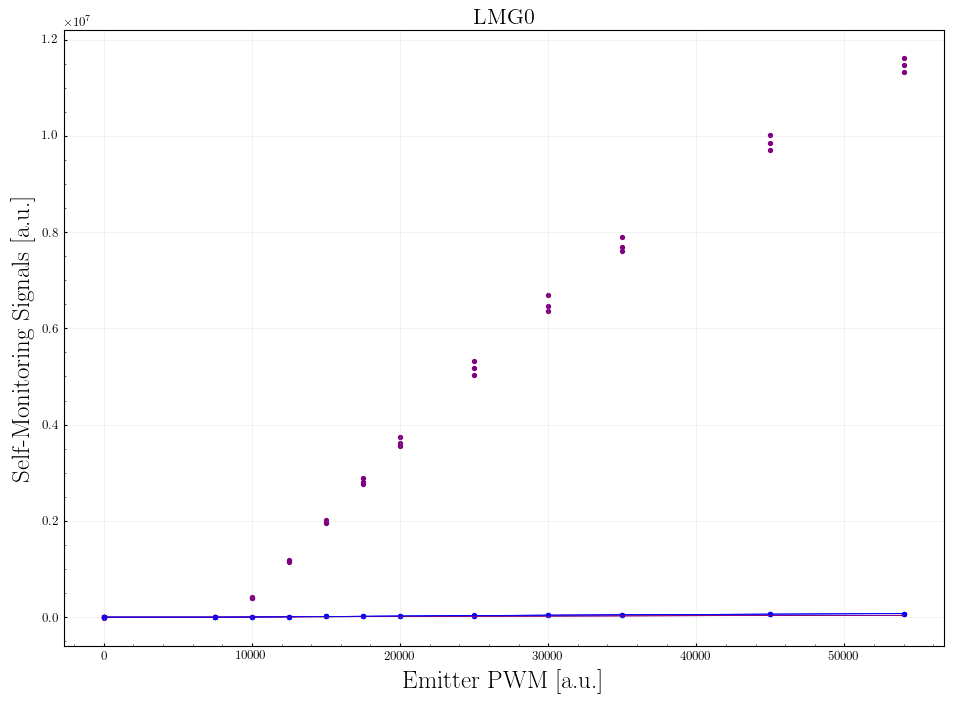

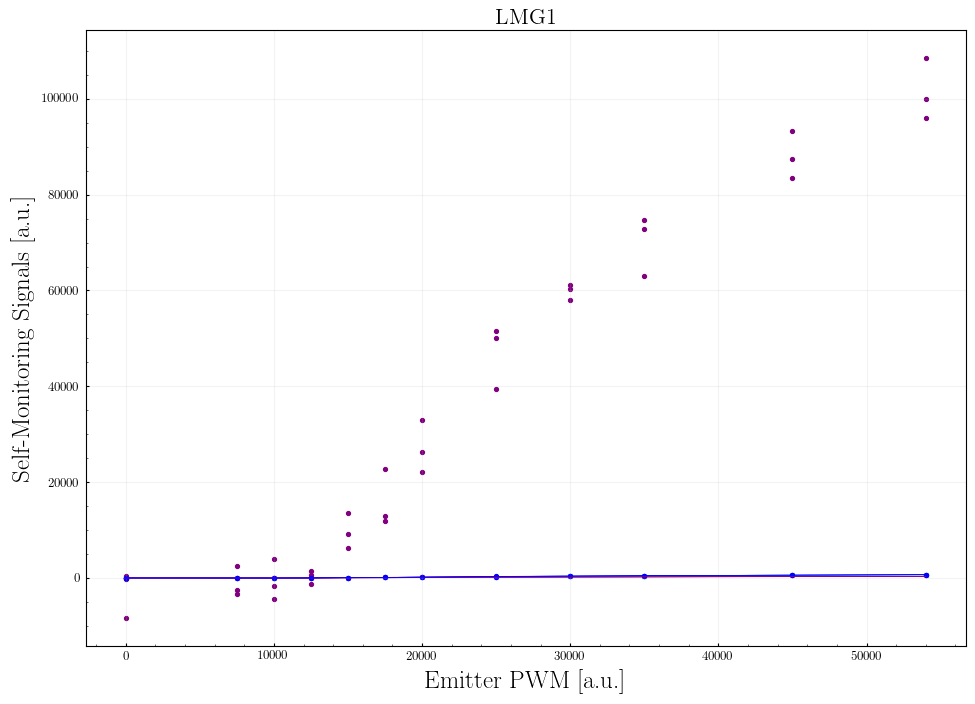

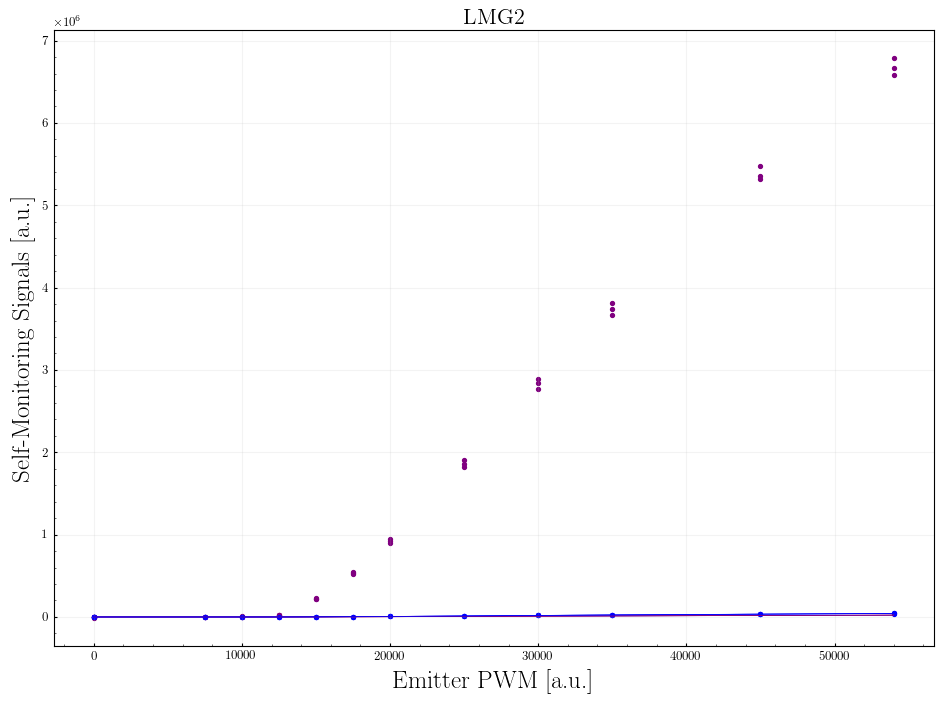

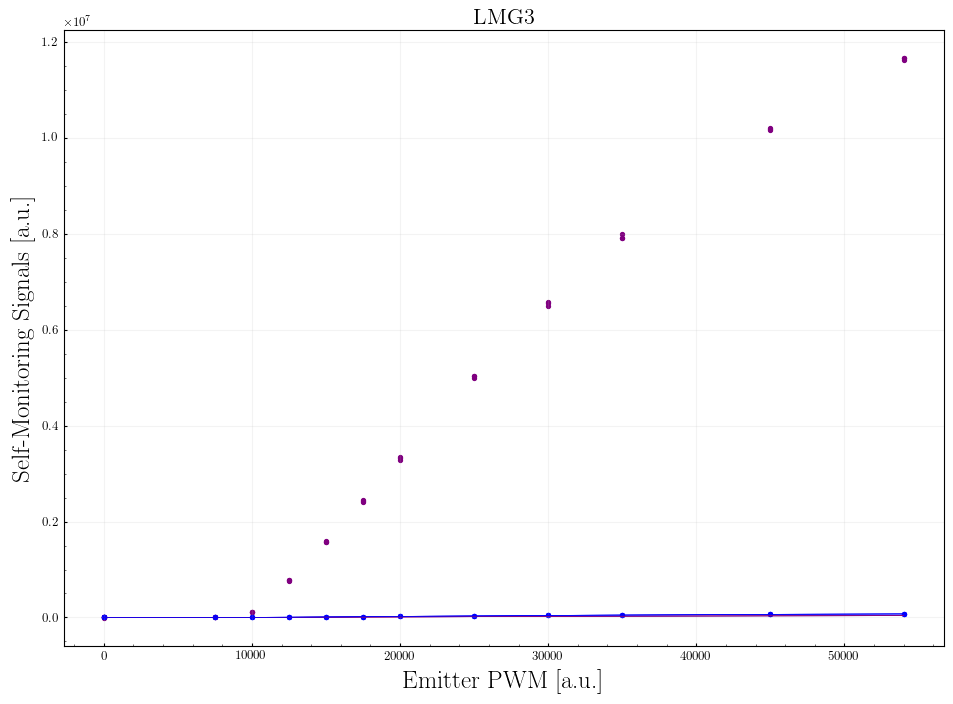

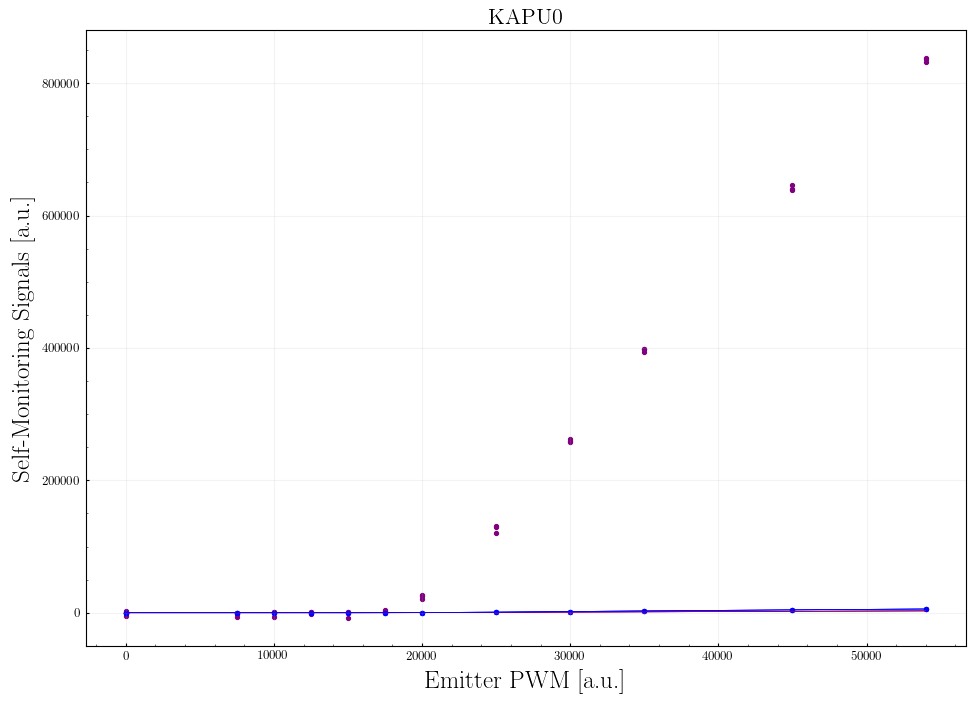

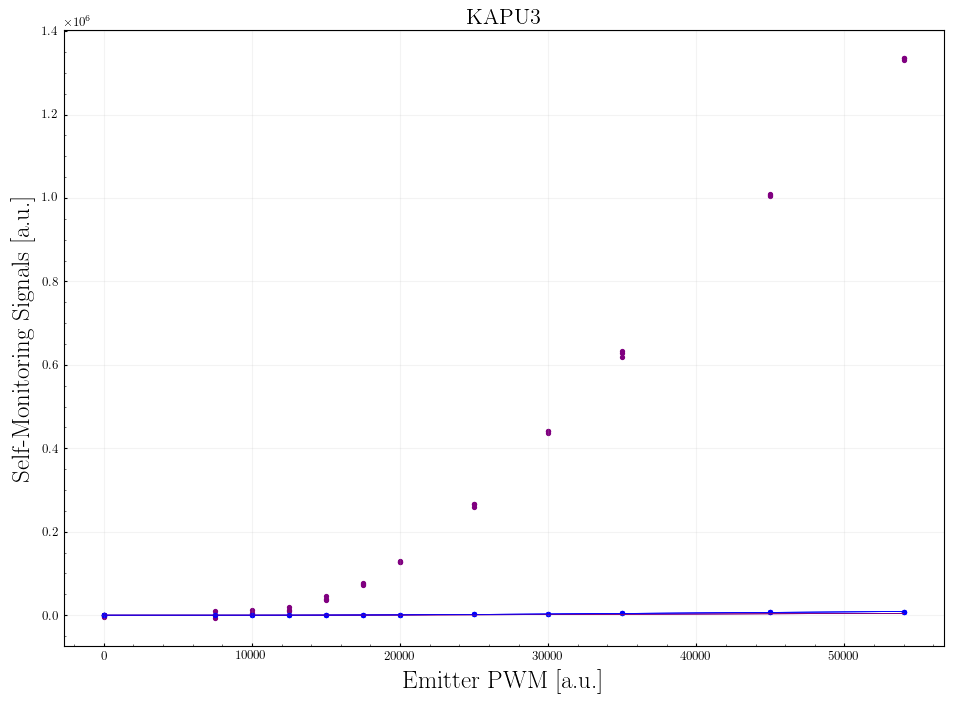

In [10]:
data_dict = {}


for flasher in ['lmg0', 'lmg1', 'lmg2', 'lmg3', 'kapu0', 'kapu3']:
    ### 'lmg0', 'lmg1', 'lmg2', 'lmg3', 'kapu0', 'kapu3'
    
    
    data_dict[flasher] = {}
    data_dict[flasher]["sipm_data"] = {}
    data_dict[flasher]["pd_data"] = {}
    
    
    lmg1_app = '_A'
        
    # 'lmg0', 'lmg1_A', 'lmg1_B', 'lmg2', 'lmg3', 'kapu0', 'kapu3'
    #flm_=flm_.decode()
    fig = plt.figure(figsize=(10,7), facecolor="w")
    ax = fig.add_axes([0.08,0.08,0.88,0.88])
    ####
    
    for sipm_pwm_ in f_['metadata']['sipm_pwm'][()]:#[:2]: 
        
        
        data_dict[flasher]["sipm_data"][str(sipm_pwm_)] = {}
        
        
        if not 'lmg1' in flasher:
            flasher_pd = flasher
        elif 'lmg1' in flasher:
            flasher_pd = flasher + lmg1_app#flasher_pd
        
        
        plotval = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcA']['sum'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        #print(plotval)
        #print(flasher)
        try:
            plotval = plotval - all_data[sipm_pwm_][flasher_pd][0]['adcA']['sum'].mean()
            #print(all_data[sipm_pwm_][flasher_pd][0]['adcA']['peak'].mean(),'\n\n')
            #plotval = plotval/np.max(plotval)
        except:
            print('no flasher pwm 0')
        
        ax.plot(
            f_['metadata']['flasher_pwm'][()],
            plotval/10**3,
            color="purple",
        )
        plt.scatter(
            f_['metadata']['flasher_pwm'][()],
            plotval/10*3,
            color="purple",
            label='adcA vs flasher-pwm'
        )
        
        
        data_dict[flasher]["pd_data"]['adcA'] = {}
        data_dict[flasher]["pd_data"]['adcA']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["pd_data"]['adcA']['adcA_peak_mean'] = 10*plotval
        data_dict[flasher]["pd_data"]['adcA']['adcA_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcA']['peak'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        
        plotval = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcB']['sum'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        try:
            plotval = plotval - all_data[sipm_pwm_][flasher_pd][0]['adcB']['sum'].mean()
            #plotval = plotval/np.max(plotval)
        except:
            print('no flasher pwm 0')
        
        ax.plot(
            f_['metadata']['flasher_pwm'][()],
            plotval/10**3,
            color="blue",
        )
        
        ax.scatter(
            f_['metadata']['flasher_pwm'][()],
            plotval/10**3,
            color="blue",
            label='adcB vs flasher-pwm'
        )
        
        #print(plotval)
        
        data_dict[flasher]["pd_data"]['adcB'] = {}
        data_dict[flasher]["pd_data"]['adcB']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["pd_data"]['adcB']['adcB_peak_mean'] = 10*plotval
        data_dict[flasher]["pd_data"]['adcB']['adcB_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcB']['peak'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        
        
    
    ax.set_title(flasher.upper(), fontsize=16)
    
    #ax.set_ylim(-1, 10)
    
    ax.set_xlabel("Emitter PWM [a.u.]", fontsize=18)
    
    ax.set_ylabel("Self-Monitoring Signals [a.u.]", fontsize=18)
    
    ax.grid('both')

    
    #ax.legend(loc='best')
    
    
    #fig.savefig('/home/ecp/test_folder/MA/self_monitoring_Colloquium_lmg0.png', dpi=300)
    
    

In [11]:
#data_dict

In [ ]:
"""
sipm_pwm = f_['metadata']['sipm_pwm'][()][-1]

flasher = 'lmg0'

fpwm_ = f_['metadata']['flasher_pwm'][()][-3]



wf_indices = np.linspace(0, 99, 100)

delays = []

for wf_index in wf_indices:
    wf_index = int(wf_index)
    delay = all_data[sipm_pwm_][flasher][fpwm_]['tdc0'][wf_index][0][2] - all_data[sipm_pwm_][flasher][fpwm_]['tdc3'][wf_index][0][2] 
    delays.append(delay)

delays = np.array(delays)

print('mean: ', np.mean(delays))
print('std: ', np.std(delays))
print('min: ', np.min(delays))
print('max: ', np.max(delays))


plt.hist(delays)
plt.show()
"""

## Classes and Functions to Load and Process The Raw Data for Intensity Measurements (PD and PMT):

In [18]:
class single_PD_data:

    def __init__(self,
                 hemisphere='51',
                 pwm=54000,
                 temp=-20,
                 diode='LMG520',
                 target='1',
                 coarse=1, fine=20,
                 mode='default',
                 batch='batch2'):
        
        """ This class is to load and pre-process data of one PD-Picoamp measurement set (PD).
            We use this in further functions for plotting (multiple) PD dataset etc. """

        self.diode = diode
        
        self.target = target
        
        if 'LMG' in diode:
            self.driver = 'lmg' + self.target
        elif 'KAPU' in diode:
            self.driver = 'kapu' + self.target

        self.pwm = pwm
        
        self.coarse = coarse
        self.fine = fine
        
        self.mode = mode

        self.temp = temp
        
        self.batch = batch
                

        
        # the file path is one of the very first things one wants to adjust here in the following lines
        h5_file_path = f"/home/ecp/disk1/pocam_data/{self.batch}/prod_characterization_{hemisphere}/"

        h = h5.File(h5_file_path+self.diode, 'r')
        
        
        if 'LMG' in diode:

            #pico_signal_LMG405_lmg1_{self.pwm}_{self.coarse}-{self.fine}_{self.temp}C.npy
            vals = h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)+'C']
            self.vals = np.array( vals.get('intensity_signal') )
            #self.vals = np.delete(self.vals, 0)
            
            #pico_dpg_LMG405_lmg1_{self.pwm}_{self.coarse}-{self.fine}_{self.temp}C.npy
            bg_vals = h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)+'C']
            self.bg_vals = np.array( bg_vals.get('intensity_bg') )
            #self.bg_vals = np.delete(self.bg_vals, 0)

            h.close()

        elif 'KAPU' in diode:
            #pico_signal_LMG405_lmg1_{self.pwm}_{self.coarse}-{self.fine}_{self.temp}C.npy
            self.vals = np.array( h[self.driver+'/'+str(self.pwm)+'/'+self.mode+'/'+str(self.temp)+'C'].get('intensity_signal') )
            #self.vals = np.delete(self.vals, 0)

            #pico_dpg_LMG405_lmg1_{self.pwm}_{self.coarse}-{self.fine}_{self.temp}C.npy
            self.bg_vals = np.array( h[self.driver+'/'+str(self.pwm)+'/'+self.mode+'/'+str(self.temp)+'C'].get('intensity_bg') )
            #self.bg_vals = np.delete(self.bg_vals, 0)
                

        h.close()

        self.mean_bg_vals = np.mean(self.bg_vals)
        self.std_bg_vals = np.std(self.bg_vals)

        
        self.signal_vals = self.vals - self.mean_bg_vals
        self.mean_signal_vals = np.mean(self.signal_vals)
        self.mean_signal_vals = -1 * self.mean_signal_vals 
        # for plotting and practical purpose we just invert the raw output to have pos. values
        self.std_signal_vals = np.std(self.signal_vals)
        
        
        self.mean_signal_err = np.sqrt( self.std_signal_vals**2 + self.std_bg_vals**2 )
        
        

#result = single_PD_data()        
                

In [19]:
# Then PMT data:

class single_pmt_data:


    def __init__(self,
                 hemisphere='51',
                 pwm=54000,
                 temp=-20,
                 target='1',
                 coarse=1, fine=20,
                 mode='default',
                 diode='LMG405',
                 info=False,
                 batch='batch2'):
        
        """ This class is to load and pre-process data of one pmt measurement set.
            We use this in the function display_pmt_data(). """

        
        self.diode = diode
        
        self.hemisphere = hemisphere
        
        self.target = target
        
        if 'LMG' in diode:
            self.driver = 'lmg' + self.target
        elif 'KAPU' in diode:
            self.driver = 'kapu' + self.target

        self.pwm = pwm
        
        self.coarse = coarse
        self.fine = fine
        
        self.mode = mode

        self.temp = temp
        
        self.batch = batch
        
                
        
        
        # the file path is one of the very first things one wants to adjust here in the following lines
        h5_file_path = f"/home/ecp/disk1/pocam_data/{self.batch}/prod_characterization_{self.hemisphere}/"

        h = h5.File(h5_file_path+self.diode, 'r')
        
        
        

        if 'LMG' in diode:
            if self.temp != "25C_precheck":
                self.pmt_time_ns = np.array( h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)+'C'].get('pmt_time_ns') )
                self.pmt_signal = np.array( h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)+'C'].get('pmt_signal') )
                self.pmt_trigger = np.array( h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)+'C'].get('pmt_trigger') )
            else:
                self.pmt_time_ns = np.array( h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)].get('pmt_time_ns') )
                self.pmt_signal = np.array( h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)].get('pmt_signal') )
                self.pmt_trigger = np.array( h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)].get('pmt_trigger') )
        elif 'KAPU' in diode:
            if self.temp != "25C_precheck":
                self.pmt_time_ns = np.array( h[self.driver+'/'+str(self.pwm)+'/'+self.mode+'/'+str(self.temp)+'C'].get('pmt_time_ns') )
                self.pmt_signal = np.array( h[self.driver+'/'+str(self.pwm)+'/'+self.mode+'/'+str(self.temp)+'C'].get('pmt_signal') )
                self.pmt_trigger = np.array( h[self.driver+'/'+str(self.pwm)+'/'+self.mode+'/'+str(self.temp)+'C'].get('pmt_trigger') )
            else:
                self.pmt_time_ns = np.array( h[self.driver+'/'+str(self.pwm)+'/'+self.mode+'/'+str(self.temp)].get('pmt_time_ns') )
                self.pmt_signal = np.array( h[self.driver+'/'+str(self.pwm)+'/'+self.mode+'/'+str(self.temp)].get('pmt_signal') )
                self.pmt_trigger = np.array( h[self.driver+'/'+str(self.pwm)+'/'+self.mode+'/'+str(self.temp)].get('pmt_trigger') )
                
        h.close()
        
        
        processed_data = {}
        processed_data['integrated_signal'] = []
        processed_data['peak'] = []
        processed_data['peak_time'] = []
        processed_data['trigger_rising_edge'] = []
        processed_data['start_integration'] = []
        processed_data['end_integration'] = []
        
        
        self.data_mv_signal = list( np.zeros( len(self.pmt_signal) ) )
        
        for i in range(len(self.pmt_signal)):
            
            
            self.data_mv_signal[i] = np.abs( self.pmt_signal[i] )

            self.peak = np.max(self.data_mv_signal[i])
            peak_index = np.where(self.data_mv_signal[i] == self.peak)[0][0]
            self.peak_time = self.pmt_time_ns[peak_index]
            
            try:
                
                # interpolate the shape of the pulse detected by the PMT:
                self.interpolation = scipy.interpolate.InterpolatedUnivariateSpline(self.pmt_time_ns, self.data_mv_signal[i])


                left_times = self.pmt_time_ns[self.pmt_time_ns < self.pmt_time_ns[peak_index]]

                left_data = self.data_mv_signal[i][:len(left_times)]

                left_zero_indices = [i_ for i_ in range(len(left_times)) if left_data[i_]==0]

                self.start = self.pmt_time_ns[np.max(left_zero_indices)]



                right_times = self.pmt_time_ns[self.pmt_time_ns > self.pmt_time_ns[peak_index]]

                right_data = self.data_mv_signal[i][peak_index+1:]

                right_zero_indices = [i_ for i_ in range(len(right_times)) if right_data[i_]==0]

                self.end = right_times[np.min(right_zero_indices)]


                """
                print('integral start time: ', start)
                print('peak time: ', peak_time)
                print('integral end time: ', end)
                print('integration time: ', end-start)
                """

                # we want to have a measure on the total amount of light that hit the PMT over the emitted pulse 
                # by integrating the ouput signal/voltage over the (rough) time of the pulse duration:
                self.integrated_signal = scipy.integrate.quad(self.interpolation, self.start, self.end)[0]


                # we also want to track when the trigger rising edge arrived/was detected
                # therefore we search for the first time when the trigger signal exceeded a threshold of 1300 [mV]:
                found_rising_edge = False
                j = 0
                while found_rising_edge == False and j < len(self.pmt_time_ns):
                    if self.pmt_trigger[i][j] >= 1300:
                        self.rising_edge_time = self.pmt_time_ns[j]
                        found_rising_edge = True
                    else:
                        j += 1



                processed_data['integrated_signal'].append(self.integrated_signal)
                processed_data['peak'].append(self.peak)
                processed_data['peak_time'].append(self.peak_time)
                processed_data['trigger_rising_edge'].append(self.rising_edge_time)
                processed_data['start_integration'].append(self.start)
                processed_data['end_integration'].append(self.end)
                
                
            except Exception as e_:
                print(f"While trying to process data of the {i}-th waveform an error ocurred: ", e_)
                self.pmt_processed = False


        if info == True:
            try:
                print("\nGiving some info on the processed PMT data: \n")
                print("number of processed waveforms: ", len(processed_data['integrated_signal']), " out of: ", len(self.pmt_signal), " total waveforms taken" )
                print("mean integrated pmt signal: ", round( np.mean(np.array(processed_data['integrated_signal'])), 2 ), " [mV x ns]", "std of integrated pmt signal: ", round( np.std(np.array(processed_data['integrated_signal'])), 2 ), " [mV x ns]")
                print("highest integrated pmt signal: ", round( np.max(np.array(processed_data['integrated_signal'])), 2 ), " [mV x ns]", "found at waveform with index: ", np.where(np.array(processed_data['integrated_signal']) == np.max(np.array(processed_data['integrated_signal'])))[0] )
                print("lowest integrated pmt signal: ", round( np.min(np.array(processed_data['integrated_signal'])), 2 ), " [mV x ns]")
                print("mean peak value: ", round( np.mean(np.array(processed_data['peak'])), 2 ), " [mV]")
                print("highest peak value: ", round( np.max(np.array(processed_data['peak'])), 2 ), " [mV]", "found at waveform with index: ", np.where(np.array(processed_data['peak']) == np.max(np.array(processed_data['peak'])))[0] )
                print("lowest peak value: ", round( np.min(np.array(processed_data['peak'])), 2 ), " [mV]")
                print("mean time of integration lasted from: ", round( np.mean(np.array(processed_data['start_integration'])), 2 ), " [ns] until ", round( np.mean(np.array(processed_data['end_integration'])), 2 ), " [ns] with std of integration time of: ", round( np.std(np.mean(np.array(processed_data['end_integration'])) - np.mean(np.array(processed_data['start_integration']))), 2 ) )
                print("mean rising edge of the trigger was at: ", round( np.mean(np.array(processed_data['trigger_rising_edge'])), 2 ), " [ns] with std of: ", round( np.std(np.array(processed_data['trigger_rising_edge'])), 2 ) )
            except Exception as e:
                print("During the attempt to give some info on the processed PMT data an error ocurred: ", e)
        else:
            pass
            
        
            
            
            """
            print("integrated pmt signal: ", self.integrated_signal, " [mV x ns]")
            print("peak value of datapoints: ", self.peak, " [mV]")
            print("the time of integration lasted from: ", self.start, " [ns] until ", self.end, " [ns]")
            print("the rising edge of the trigger was at: ", self.rising_edge_time, " [ns] ",
                  "and the peak of the POCAM light detection was at: ", self.peak_time, " [ns]")
            """
            
        processed_data['integrated_signal'] = np.array( processed_data['integrated_signal'] )
        processed_data['peak'] = np.array( processed_data['peak'] )
        processed_data['peak_time'] = np.array( processed_data['peak_time'] )
        processed_data['trigger_rising_edge'] = np.array( processed_data['trigger_rising_edge'] )
        processed_data['start_integration'] = np.array( processed_data['start_integration'] )
        processed_data['end_integration'] = np.array( processed_data['end_integration'] )
        
        
        self.processed_data = processed_data
        
        """
        print(self.processed_data['integrated_signal'])
        print("mean: ", np.mean( self.processed_data['integrated_signal'] ) )
        print("rel. std: ", np.std( self.processed_data['integrated_signal']) / np.mean( self.processed_data['integrated_signal'] )  )
        """
        #return( self.processed_data )
            



result = single_pmt_data()
    

/tmp/ipykernel_16590/4032710134.py:130: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  self.integrated_signal = scipy.integrate.quad(self.interpolation, self.start, self.end)[0]


## Classes and Functions to Process Angular Calibration Data and Calculate Number of Photons (Baseline and at Every Other Temperatures and Settings):

In [20]:
# Total Number of Emitted Photons:


class single():

    def __init__(self,file):
        self.data = h5py.File(file, 'r+')
        
        #print(self.data.keys())

        self.result = {}

        try:
            self.hemisphere_sn = self.data['meta'].attrs['AB_SN']
        except:
            print('NO METADATA ACCESSABLE')
            

    def PulseTime(self):
        self.caltrig = float(self.data['meta'].attrs['PulseTime']) * ( 10**(-6) )
        return self.caltrig


    def distance(self):
        self.distance = float(self.data['LMG405'].attrs['distance'])
        return self.distance


    def flashers(self):
        self.led = self.data.keys()
        return list(self.led)


    def meta(self):
        meta_data = self.data['meta'].attrs.keys()
        return meta_data


    def cals(self):
        # ncal = self.ncals()
        self.x = np.array(range(self.ncals()))
        return self.x


    def ncals(self):
        self.ncal = self.data['meta'].attrs['ncal']
        return self.ncal


    def meta_flasher(self,key):
        meta_data = self.data[key].attrs.keys()
        return meta_data


    def curr(self,key):
        arr = np.array(self.data.get(key))
        self.y = arr[2]*10**12
        self.y_err = arr[3]*10**12
        
        index = self.indices
        
        self.y = np.split(self.y, index+1)
        #print(self.y)
        self.y_err = np.split(self.y_err, index+1)
        
        self.y1 = []
        self.y2 = []
        
        for i in range(len(self.y)):
            self.y1.append(np.mean(self.y[i]))
            #print(f"self.y[{i}]: ", self.y[i])
            #print(f"self.y_err[{i}]: ", self.y_err[i])
            self.y2.append( np.sqrt( np.std(self.y[i])**2 + 1/len(self.y_err[i])*np.sum(np.array(self.y_err[i])**2) ) )
            
        
        #print("self.y1: ", self.y1)
        #print("self.y2: ", self.y2)
        
        return np.array([self.y1]), np.array(self.y2)
    
    
    def zenith_angles(self):
        NSIDE = 2**2
        vec = hp.ang2vec(np.pi / 2, np.pi * 3 / 4)
        ipix_disc = hp.query_strip(NSIDE, np.radians(0), np.radians(150))
        deg = np.degrees(hp.pix2ang(nside=NSIDE, ipix=ipix_disc))

        self.zenith = np.round(deg[0],2)
        self.azimuth = np.round(deg[1],2)
        self.zeniths = np.unique(self.zenith)
        self.indices = np.where(np.diff(self.azimuth) < 0)[0]
        return np.array(self.zeniths)
        
    
    def zero(self,key):
        zero_value = self.data[key].attrs['zero_data'][0]
        return zero_value
 

    def emitter(self,key):
        self.wavelength = self.data[key].attrs['flasher']
        return self.wavelength


    def wave(self,key):
        lb = self.emitter(key)[-3:]
        return float(lb)


    def plot(self,key):
        x = self.cals()[1::]
        y1 = self.curr(key)[0][1::]
        y2 = self.curr(key)[1][1::]
        ncal = self.ncals()

        lb = self.emitter(key)

        mean_y1 = np.mean(y1)
        mean_y2 = np.mean(y2)

        fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, gridspec_kw={'height_ratios': [6, 2]})
        plot_args = dict( linestyle = '', marker = 'o')

        ax1.scatter(x,y1, s = 10, label= '%s NIST' %lb, color ='green', **plot_args)
        ax1.scatter(x,y2, s = 10, label= '%s PD' %lb, color = 'red', **plot_args)

        ax1.set_ylabel('I [pA]')
        ax1.grid(which = 'both')

        ax2.scatter(x, (y1-mean_y1), s = 2, color='green', **plot_args)
        ax2.scatter(x, (y2-mean_y2), s = 2, color='red', **plot_args)
        ax2.plot(x, x*0, color='black')
        ax2.set_ylabel('')
        ax2.grid(which = 'both')

        print('%0.4f' %mean_y1, '+/-' , '%0.4f' %(np.std(y1)/np.sqrt(ncal)), '///', lb, 'NIST')
        print('%0.4f' %mean_y2, '+/-' , '%0.4f' %(np.std(y2)/np.sqrt(ncal)), '///', lb, 'PD')
        #plt.ylim(top = 0.2, bottom= -0.4)
        ax1.legend(bbox_to_anchor=(1,1), loc="upper left")


    def hist(self,key):
        lb = self.emitter(key)
        y1 = self.curr(key)[0][1::]
        y2 = self.curr(key)[1][1::]
        sns.histplot(y1, bins = 12, stat = 'count')
        plt.title('%s' %lb)
        plt.xlabel('I [pA]')
        plt.show()

        sns.histplot(y2, bins = 12, stat = 'count')
        plt.title('%s' %lb)
        plt.xlabel('I [pA]')
        plt.show()


    def close(self):
        self.data.close()

In [21]:
def calc_photons(I, lb, Resp, T, geo):
    hc = 1.98644586*10**(-25)
    N = I*T*lb*geo/(Resp*hc)
    return N


def int_func(x, k, w, x0, y0):
    return (k / (1 + np.exp(-w * (x - x0))) + y0) * np.sin(x)


def integrate(popt):
    return scipy.integrate.quad(lambda x: int_func(x,*popt), 0, np.pi)[0]


def sigmoid(x, k, w, x0, y0):
        return k / (1. + np.exp(-w * (x - x0))) + y0
    

In [22]:
# And the actual calculation for the number of emitted photons:

def number_of_photons_baseline(hemisphere = '23',
                               diode = 'LMG405',
                               path = None,
                               printing = False,
                               batch='batch2'):
    """ The calculated number is the total number of emitted photons per pulse for the selected hemisphere and emitter.
        The data is based on the light emission for the selected emitter operated at
        PWM: 54000, pulsePer: 12, coarse:1 and fine: 20 or mode: default
    """    
        
    
    x_pre = np.array([62.70,60.16,57.69,55.16,52.62,50.22,47.54,45.14,42.67,40.27,37.66,34.99,32.59,30.05,27.58,25.18,22.64,20.24,17.63,15.09,12.69,10.08,7.54,5.07,2.67,0.34])

    y_pre = np.array([0.960,0.966,0.968,0.969,0.971,0.975,0.980,0.981,0.990,0.990,0.991,0.991,0.994,0.997,1.000,1.000,1.000,1.003,1.001,1.004,1.004,1.006,1.006,1.006,1.006,1.007])

    x_values = np.array([65.17,67.64,70.18,70.11,72.64,72.58,75.18,75.25,77.64,77.65,80.18,80.18,82.64,82.64,85.10,85.10,87.64,87.63,90.10,90.16,90.26,92.62,95.09,95.08,97.56,97.55,100.16,100.01,102.55,102.54,105.01,105.00,107.55,107.54,110.01,110.07,112.61,112.54,115.08,115.15,117.62,117.62,119.95,119.95,125.,125.,130.,130.,135.,135.,140.,140.,150.,150.,160.,160.])

    y_values = np.array([0.958,0.953,0.939,0.949,0.909,0.934,0.874,0.903,0.832,0.860,0.783,0.798,0.725,0.726,0.668,0.656,0.606,0.577,0.542,0.497,0.480,0.416,0.416,0.337,0.353,0.262,0.293,0.186,0.233,0.122,0.176,0.069,0.125,0.025,0.075,0.005,0.039,-0.001,0.014,-0.001,0.006,-0.002,0.005,-0.002,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.])

    x_air = np.concatenate([np.flip(x_pre), x_values[::2]])[10:]
    x_ice = np.concatenate([np.flip(x_pre), x_values[1::2]])
    y_air = np.concatenate([np.flip(y_pre), y_values[::2]])[10:]
    y_ice = np.concatenate([np.flip(y_pre), y_values[1::2]])

    popt_air, _ = curve_fit(sigmoid, x_air, y_air, p0 = [1.1, -1.0, 95, -0.001], maxfev = 1000)
    popt_ice, _ = curve_fit(sigmoid, x_ice, y_ice, p0 = [1.1, -1.0, 95, -0.001], maxfev = 1000)



    dictionary = {}

    file_path = f'/home/ecp/disk1/pocam_data/{batch}/prod_characterization_{hemisphere}/'
    file_names = ['cali_flange_']
    

    for filename in file_names:

        hem = single(file_path+filename+hemisphere)


        currents = []
        parameters = []

        
        emitters = [diode]

        hem.zenith_angles()
        
        for emitter in emitters:
            
            y, y_err = hem.curr(emitter)
                        
                
            y_norm = hem.zero(emitter)
            currents.append(y_norm)

            
            val=np.array( y[0] )*10**(-12) / y_norm     # val=np.mean(y[0],axis=0)/y_norm
            

            #zenith = np.append(h5.zeniths(),newzen)
            zenith = np.array( hem.zenith_angles() )
            zenith = zenith*np.pi/180   # convert degree to radian

            
            values = val*sigmoid(zenith,*popt_ice)/sigmoid(zenith,*popt_air)         # modify values from air to ice
            
            
            sim_mismatch = 0.025  ### 2,5% is the relative error given by Felix for the simulation of ice vs air behaviour
            
            
            data_points_err = np.sqrt( (y_err*10**(-12))**2 + (np.array(values)*sim_mismatch)**2 )

            
            popt, pcov = curve_fit(sigmoid, np.array(zenith), np.array(values),
                                   p0 =[1.1,-5.,1.5,-0.005],
                                   #sigma=data_points_err,
                                   #absolute_sigma=True,
                                   maxfev = 1000)
            
            print("popt:")
            print(popt)
            print("pcov:")
            print(pcov)

            
            parameters.append(popt)

            
            zenith_plot = np.linspace(0, np.pi, 1000)
            plt.plot(zenith_plot, sigmoid(zenith_plot, *popt), color='purple')
            plt.scatter(zenith, values, label= 'Measured Data', s = 15)
            plt.grid(which = 'both')
            plt.xlabel(r'$\theta$ [rad]', fontsize=13)
            plt.ylabel('Intensity [a.u.]', fontsize=13)
            plt.legend(loc = 'center right', fontsize=11, frameon=True)
            plt.tick_params(labelsize=11)
            plt.grid('both')
            plt.show()
            plt.close()

            

            # The values are taken from NIST-PD datasheet, and if the typical CWL of POCAM emission is shifted to 
            # a wl value that falls between two explicitely given/tested wl values by NIST the corresponding 
            # Responsitivity value wwas simply interpolated between the two next neighbours while 
            # for the error the largest one in that regime was taken to be safe
            NIST = {'LMG365' : [0.1416,0.00380], 'LMG405' : [0.1800,0.00300], 'LMG450' : [0.2111,0.00240], 'LMG520' : [0.2610,0.00100],
                    'KAPU405' : [0.1800,0.00300], 'KAPU465' : [0.2220,0.00200]}

            hc = 1.98644586*10**(-25)                                                     # m^3 kg / s^2

            sn = str(int(hem.hemisphere_sn))
            lb = float(emitter[-3:])
            
            caltrig =  hem.PulseTime() # 12*17.067 * 10**(-6)                             # s
            
            current = np.abs(y_norm)  # *10**-12                                          # A
            

            A_PD = 1                                                                      # cm^2 #Fläche PD
            dist = 96  # hem.distance() , in cm
            d = float(dist)                                                               # distance of equator of flange to PD surface in cm
            Geo = d**2/A_PD

            num = calc_photons(current, lb*10**(-9), NIST[emitter][0], caltrig, Geo)
            
            
            
            # MC sampling for photon number uncertainty
            N_mc = 1000  # number of MC samples
            param_samples = np.random.multivariate_normal(popt, pcov, size=N_mc)

            photon_samples = []
            for sample in param_samples:
                integral = integrate(sample) * 2 * np.pi
                photon_samples.append(integral * num)

            photons = np.mean(photon_samples)
            photons_int_err = np.std(photon_samples)
            
            
            
            
            ##############
            # Consistency check for doing MC sampling based on inferred data and their uncertainties and taking the mean,
            # or directly do the integration only once for the inferred data 
            photons_old = integrate(popt) * 2*np.pi * num #* 10**(-10)
            ##############
            


            
            if printing == True:
                print('wavelength: ', lb, 'nm')
                mu = '\u03bc'
                print('pulsePer: ', caltrig / 10**(-6), f'{mu}s')
                print('current_norm: ', current/10**(-12), ' [pA]')
                print('number of photons: ', photons * 10**(-10), f'10^10')
            else:
                pass
            
            
            
            #### APPEND PHOTON NUMBER TO META DATA OF FILE
            key = 'PhotonNumber'
            hem.result[emitter] = photons #* 10**3
            
            
            
            
            
            ### Error calculation for baseline photons:
            
            delta_d = 0.5  # error of d in cm
            photons_d_err = 2 * delta_d/d * photons
            
            
            delta_R = NIST[emitter][1]
            R = NIST[emitter][0]
            photons_R_err = delta_R/R * photons
            
            
            rel_delta_I = np.sqrt( 1/len(y_err) * np.sum( (y_err * 10**(-12))**2 / y[0]**2 ) )
            photons_I_err = rel_delta_I * photons
                        
                
            photons_point_source_approx_err = 0.01 * photons
            
            
            photons_sim_mismatch_err = 0.025 * photons
            
            
            """
            print("photons_d_err: ", np.abs(photons_d_err))
            print("photons_R_err: ", np.abs(photons_R_err))
            print("photons_int_err: ", photons_int_err)
            print("photons_I_err: ", photons_I_err)
            print("photons_point_source_approx_err: ", photons_point_source_approx_err)
            """
            
        
            photons_sys_err = np.abs(photons_d_err) + np.abs(photons_R_err) + photons_point_source_approx_err
            photons_stat_err = np.sqrt( photons_int_err**2 + photons_I_err**2 + photons_sim_mismatch_err**2 )
            
            hem.result[emitter + '_rel_sys_error'] = photons_sys_err / photons
            hem.result[emitter + '_rel_stat_error'] = photons_stat_err / photons
            
            
            """
            print("baseline photons: ", photons)
            print("baseline photons rel. sys. err: ", photons_sys_err / photons)
            print("baseline photons rel. stat. err: ", photons_stat_err / photons)
            print("baseline photons old: ", photons_old)
            """
            
            
            photons_mean_sys_err = np.abs(photons_d_err) + np.abs(photons_R_err) + photons_point_source_approx_err
            photons_mean_stat_err = 1/np.sqrt(50) * np.sqrt( photons_int_err**2 + photons_I_err**2 + photons_sim_mismatch_err**2 )
            
            hem.result[emitter + '_mean_rel_sys_error'] = photons_mean_sys_err / photons
            hem.result[emitter + '_mean_rel_stat_error'] = photons_mean_stat_err / photons
            

            
            


    dictionary['hemisphere_'+hemisphere] = hem.result
    dictionary['sn'] = sn

    hem.close()




    if path != None:
        # Save the dictionary as a JSON file
        with open(path, 'w') as file:
            json.dump(dictionary, file, indent=4)
            print(f"Dictionary saved to {path}")
    else:
        pass
    
        
    
    
    return(photons, hem)

In [23]:
def number_of_photons(hemisphere='03',
                      temp = 25,
                      diode = 'LMG405',
                      target = '1',
                      pwm = 54000,
                      coarse = 2, fine = 20,
                      mode = 'default',
                      path = None,
                      batch='batch2'):
    
    
    try:
        data_pd_obj = single_PD_data(hemisphere=hemisphere, pwm=pwm, temp=temp, target=target, 
                                 coarse=coarse, fine=fine, mode=mode, diode=diode, batch=batch)
        data_pd = data_pd_obj.mean_signal_vals
        data_pd_rel_err = data_pd_obj.mean_signal_err / data_pd
        #print('data_pd_rel_err: ', data_pd_rel_err)
        
    except Exception as e:
        print('Could not find PD data...')
        print(e)
    
    
    try:
        norm_pd_obj = single_PD_data(hemisphere=hemisphere, pwm=54000, temp=25, target=target, 
                                 coarse=1, fine=20, mode='default', diode=diode, batch=batch)
        norm_pd = norm_pd_obj.mean_signal_vals
        norm_pd_rel_err = norm_pd_obj.mean_signal_err / norm_pd
        #print('norm_pd_rel_err: ', norm_pd_rel_err)
        
    except:
        print('Could not find the baseline PD data at 25 °C, PWM: 54000, coarse: 1 and fine: 20 or mode: default')
    
    
    try:
        baseline, hem = number_of_photons_baseline(hemisphere=hemisphere, diode=diode, batch=batch)
        
        emitted_photons_pd = data_pd / norm_pd * baseline
        
        baseline_rel_sys_err = hem.result[diode + '_rel_sys_error']
        baseline_rel_stat_err = hem.result[diode + '_rel_stat_error']
        
        emitted_photons_pd_rel_err = np.sqrt( data_pd_rel_err**2 + norm_pd_rel_err**2 + baseline_rel_stat_err**2 + baseline_rel_sys_err**2 )
        #print("emitted_photons_pd_rel_err: ", emitted_photons_pd_rel_err)
        
        baseline_mean_rel_sys_err = hem.result[diode + '_mean_rel_sys_error']
        baseline_mean_rel_stat_err = hem.result[diode + '_mean_rel_stat_error']
        
        emitted_photons_pd_mean_rel_err = np.sqrt( (data_pd_rel_err/np.sqrt(100))**2 + (norm_pd_rel_err/np.sqrt(100))**2 + baseline_mean_rel_stat_err**2 + baseline_mean_rel_sys_err**2 )
        #print("emitted_photons_pd_mean_rel_err: ", emitted_photons_pd_mean_rel_err)
        
        
        if emitted_photons_pd < 0:
            emitted_photons_pd = 0
            print('Number of photons thrown to 0, as signal was calculated to show negative amount of photons!')
        else:
            pass
        
        
    except Exception as e:
        print("Could not calculate number of photons from PD data")
        print(e)
        
    
        
    """
    processed_data['integrated_signal'] 
    processed_data['peak'] 
    processed_data['peak_time'] 
    processed_data['trigger_rising_edge'] 
    processed_data['start_integration'] 
    processed_data['end_integration'] 
    """ 
    
    
    
    try:
        data_pmt_dict = single_pmt_data(hemisphere=hemisphere, pwm=pwm, temp=temp, target=target, 
                                   coarse=coarse, fine=fine, mode=mode, diode=diode, batch=batch).processed_data
        data_pmt = np.mean( data_pmt_dict['integrated_signal'] )
        data_pmt_std = np.std( data_pmt_dict['integrated_signal'] )
        #print('PMT data: ', data_pmt)
        
    except:
        print('No PMT data for this parameter settings')
    
    
    
 
    """
    pmt_cross = {}
    pmt_pwm = []
    
    try:
        pmt_cross[power_value] = single_pmt_data(hemisphere=hemisphere, pwm=pwm, temp=temp, target=target, 
                                                 coarse=coarse, fine=fine, mode=mode, diode=diode, batch=batch).processed_data 
        pmt_pwm.append(power_value)
    except Exception as e:
        print('Could not find PMT data to cross-calibrate and calculate number of photons')
        print(e)
    """
                
    try:
        
        for norm_pwm in [54000, 45000, 35000, 30000, 25000, 20000, 15000, 10000, 7500]: 
            
            norm_pmt_dict = single_pmt_data(hemisphere=hemisphere, pwm=norm_pwm, temp=temp, target=target,
                                       coarse=1, fine=20, mode='default', diode=diode, batch=batch).processed_data
            
            if np.max( norm_pmt_dict['peak'] ) < 4500:
                break
            else:
                pass
            
        print("norm_pwm: ", norm_pwm)
        print("peak: ", np.max( norm_pmt_dict['peak'] ) )
        
        
        norm_pmt = np.mean( norm_pmt_dict['integrated_signal'] )
            
        
        norm_cross = single_PD_data(hemisphere=hemisphere, pwm=norm_pwm, temp=temp, target=target, 
                                    coarse=coarse, fine=fine, mode=mode, diode=diode, batch=batch).mean_signal_vals
        
        emitted_photons_pmt = (data_pmt / norm_pmt) * (norm_cross / norm_pd) * baseline
    
    except Exception as e:
        print("Could not conduct actual calculation of number of photons from PMT data")
        #print(e)
        
        
    try:
        final_numbers = { 'emitted_photons_pd' : round( emitted_photons_pd ),
                          'emitted_photons_pd_rel_err' : round(emitted_photons_pd_rel_err,4),
                          'emitted_photons_pd_mean_rel_err' : round(emitted_photons_pd_mean_rel_err,4),
                          'emitted_photons_pmt' : round( emitted_photons_pmt ) }
    except:
        final_numbers = { 'emitted_photons_pd' : round( emitted_photons_pd ),
                          'emitted_photons_pd_rel_err' : round(emitted_photons_pd_rel_err,4),
                          'emitted_photons_pd_mean_rel_err' : round(emitted_photons_pd_mean_rel_err,4),}
        
        
    test_numbers = {}
    test_numbers["data_pmt"] = data_pmt
    test_numbers["data_pd"] = data_pd
    
        
    if path != None:
        # Save the dictionary as a JSON file
        with open(path, 'w') as file:
            json.dump(final_numbers, file, indent=4)
            print(f"Dictionary saved to {path}")
    else:
        pass
    
    
    
    return( final_numbers, test_numbers )

## Actual Data Inference / Calculation of Number of Photons incl. its Uncertainty:

'Description of most important steps conducted':

(Fitting, Integration, Calculation of Number of Photons, Cross-calibration, Error Calculation, MC error inference, etc.)

popt:
[ 1.00823273 -6.52796028  1.60352909 -0.01355957]
pcov:
[[ 1.54574912e-04  2.19611678e-03  2.02376396e-05 -1.00021922e-04]
 [ 2.19611678e-03  7.58055940e-02  2.84709537e-04 -1.41021602e-03]
 [ 2.02376396e-05  2.84709537e-04  5.33852865e-05 -3.58411725e-05]
 [-1.00021922e-04 -1.41021602e-03 -3.58411725e-05  9.02271928e-05]]


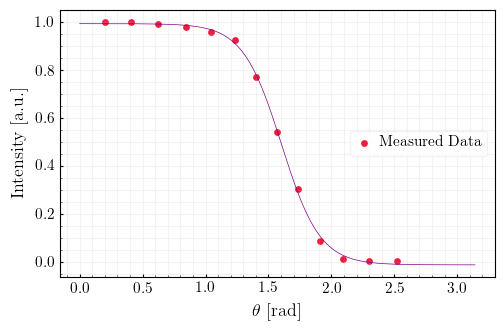

Number of photons thrown to 0, as signal was calculated to show negative amount of photons!
While trying to process data of the 5-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 7-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 16-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 19-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 20-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 43-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 55-th waveform an error ocurred:  zero-s

/tmp/ipykernel_16590/4032710134.py:130: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  self.integrated_signal = scipy.integrate.quad(self.interpolation, self.start, self.end)[0]


norm_pwm:  54000
peak:  2598.4251968503936
final_no:  {'emitted_photons_pd': 0, 'emitted_photons_pd_rel_err': 9.9792, 'emitted_photons_pd_mean_rel_err': 0.9983, 'emitted_photons_pmt': 1233319}
test_no:  {'data_pmt': 44.77057167311389, 'data_pd': -3.1624215828000006e-14}
popt:
[ 1.00823273 -6.52796028  1.60352909 -0.01355957]
pcov:
[[ 1.54574912e-04  2.19611678e-03  2.02376396e-05 -1.00021922e-04]
 [ 2.19611678e-03  7.58055940e-02  2.84709537e-04 -1.41021602e-03]
 [ 2.02376396e-05  2.84709537e-04  5.33852865e-05 -3.58411725e-05]
 [-1.00021922e-04 -1.41021602e-03 -3.58411725e-05  9.02271928e-05]]


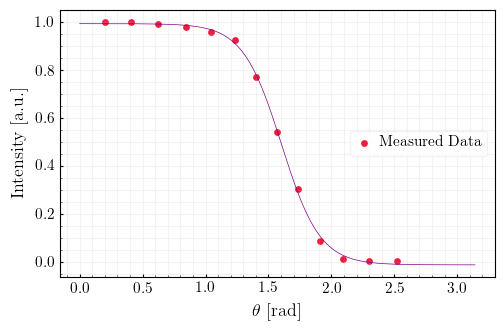

While trying to process data of the 2-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 7-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 15-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 16-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 17-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 33-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 45-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data 

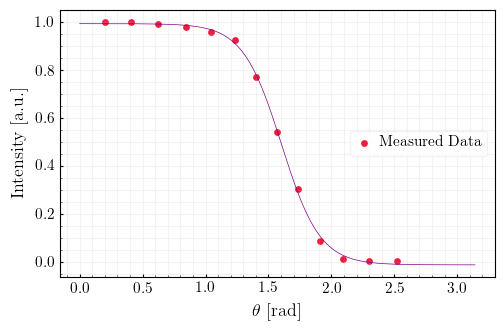

While trying to process data of the 52-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 64-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 67-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 73-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 78-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
While trying to process data of the 93-th waveform an error ocurred:  zero-size array to reduction operation maximum which has no identity
norm_pwm:  54000
peak:  2598.4251968503936
final_no:  {'emitted_photons_pd': 11733327, 'emitted_photons_pd_rel_err': 0.7259, 'emitted_photons_pd_mean_rel_err': 0.0783

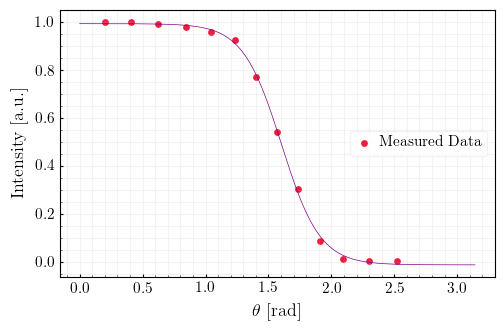

norm_pwm:  54000
peak:  2598.4251968503936
final_no:  {'emitted_photons_pd': 61964076, 'emitted_photons_pd_rel_err': 0.1461, 'emitted_photons_pd_mean_rel_err': 0.0328, 'emitted_photons_pmt': 57314792}
test_no:  {'data_pmt': 2079.8915996032797, 'data_pd': 2.2453762654700002e-12}
popt:
[ 1.00823273 -6.52796028  1.60352909 -0.01355957]
pcov:
[[ 1.54574912e-04  2.19611678e-03  2.02376396e-05 -1.00021922e-04]
 [ 2.19611678e-03  7.58055940e-02  2.84709537e-04 -1.41021602e-03]
 [ 2.02376396e-05  2.84709537e-04  5.33852865e-05 -3.58411725e-05]
 [-1.00021922e-04 -1.41021602e-03 -3.58411725e-05  9.02271928e-05]]


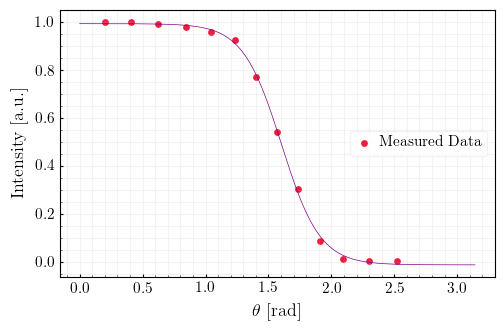

norm_pwm:  54000
peak:  2598.4251968503936
final_no:  {'emitted_photons_pd': 157234711, 'emitted_photons_pd_rel_err': 0.0677, 'emitted_photons_pd_mean_rel_err': 0.0302, 'emitted_photons_pmt': 153923876}
test_no:  {'data_pmt': 5588.919207184459, 'data_pd': 5.70092647547e-12}
popt:
[ 1.00823273 -6.52796028  1.60352909 -0.01355957]
pcov:
[[ 1.54574912e-04  2.19611678e-03  2.02376396e-05 -1.00021922e-04]
 [ 2.19611678e-03  7.58055940e-02  2.84709537e-04 -1.41021602e-03]
 [ 2.02376396e-05  2.84709537e-04  5.33852865e-05 -3.58411725e-05]
 [-1.00021922e-04 -1.41021602e-03 -3.58411725e-05  9.02271928e-05]]


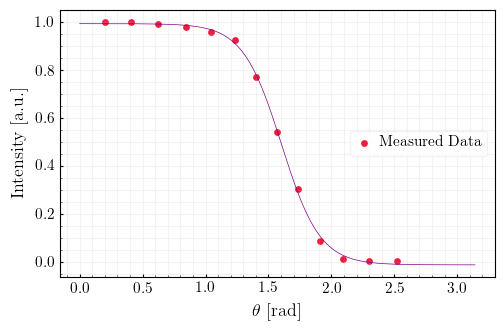

norm_pwm:  54000
peak:  2598.4251968503936
final_no:  {'emitted_photons_pd': 275460406, 'emitted_photons_pd_rel_err': 0.0511, 'emitted_photons_pd_mean_rel_err': 0.0298, 'emitted_photons_pmt': 283450329}
test_no:  {'data_pmt': 10294.586729112774, 'data_pd': 9.990018855470002e-12}
popt:
[ 1.00823273 -6.52796028  1.60352909 -0.01355957]
pcov:
[[ 1.54574912e-04  2.19611678e-03  2.02376396e-05 -1.00021922e-04]
 [ 2.19611678e-03  7.58055940e-02  2.84709537e-04 -1.41021602e-03]
 [ 2.02376396e-05  2.84709537e-04  5.33852865e-05 -3.58411725e-05]
 [-1.00021922e-04 -1.41021602e-03 -3.58411725e-05  9.02271928e-05]]


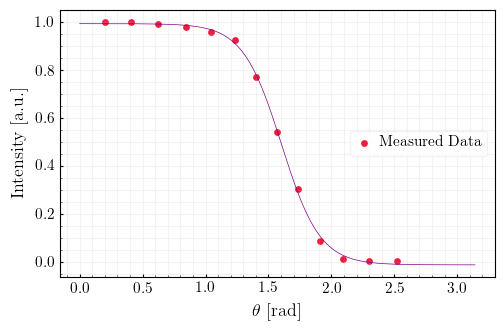

norm_pwm:  54000
peak:  2598.4251968503936
final_no:  {'emitted_photons_pd': 401858336, 'emitted_photons_pd_rel_err': 0.0452, 'emitted_photons_pd_mean_rel_err': 0.0297, 'emitted_photons_pmt': 418015734}
test_no:  {'data_pmt': 15175.820497981358, 'data_pd': 1.4568260781802e-11}
popt:
[ 1.00823273 -6.52796028  1.60352909 -0.01355957]
pcov:
[[ 1.54574912e-04  2.19611678e-03  2.02376396e-05 -1.00021922e-04]
 [ 2.19611678e-03  7.58055940e-02  2.84709537e-04 -1.41021602e-03]
 [ 2.02376396e-05  2.84709537e-04  5.33852865e-05 -3.58411725e-05]
 [-1.00021922e-04 -1.41021602e-03 -3.58411725e-05  9.02271928e-05]]


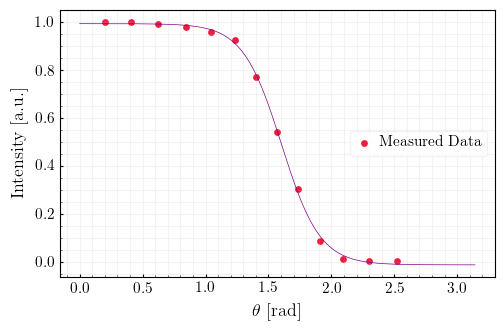

norm_pwm:  54000
peak:  2598.4251968503936
final_no:  {'emitted_photons_pd': 645270462, 'emitted_photons_pd_rel_err': 0.0424, 'emitted_photons_pd_mean_rel_err': 0.0297, 'emitted_photons_pmt': 665860741}
test_no:  {'data_pmt': 24174.645006977516, 'data_pd': 2.3393416581802005e-11}
popt:
[ 1.00823273 -6.52796028  1.60352909 -0.01355957]
pcov:
[[ 1.54574912e-04  2.19611678e-03  2.02376396e-05 -1.00021922e-04]
 [ 2.19611678e-03  7.58055940e-02  2.84709537e-04 -1.41021602e-03]
 [ 2.02376396e-05  2.84709537e-04  5.33852865e-05 -3.58411725e-05]
 [-1.00021922e-04 -1.41021602e-03 -3.58411725e-05  9.02271928e-05]]


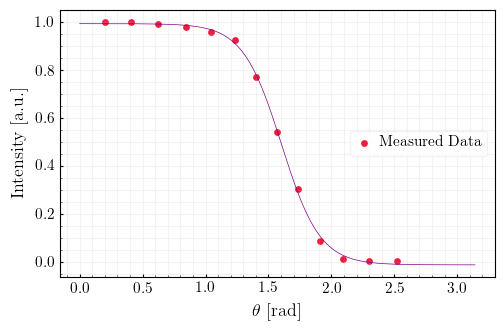

norm_pwm:  54000
peak:  2598.4251968503936
final_no:  {'emitted_photons_pd': 850652820, 'emitted_photons_pd_rel_err': 0.0418, 'emitted_photons_pd_mean_rel_err': 0.0297, 'emitted_photons_pmt': 850652820}
test_no:  {'data_pmt': 30882.933086582256, 'data_pd': 3.08385332804e-11}


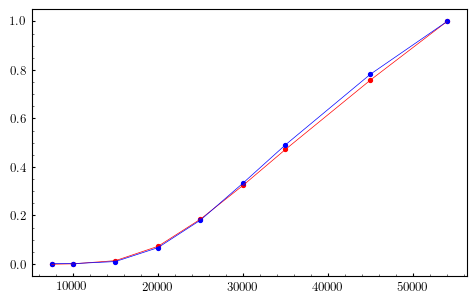

In [24]:
powers = [7500, 10000, 15000, 20000, 25000, 30000, 35000, 45000, 54000]
# [7500, 10000, 15000, 20000, 25000, 30000, 35000, 45000, 54000]

pmt = []
pd = []

for power in powers:

    final_no, test_no = number_of_photons(hemisphere='39',
                      temp = -20,
                      diode = 'KAPU465',
                      target = '1',
                      pwm = power,
                      coarse = 1, fine = 20,
                      mode = 'default',
                      path = None,
                      batch='batch2')
    
    pmt.append(test_no["data_pmt"])
    pd.append(test_no["data_pd"])
    
    print("final_no: ", final_no)
    print("test_no: ", test_no)

    
pmt = np.array(pmt)
pd = np.array(pd)
    
#print(values)


plt.plot(powers, pd/np.max(pd), color='red')
plt.scatter(powers, pd/np.max(pd), color='red')
plt.plot(powers, pmt/np.max(pmt), color='blue')
plt.scatter(powers, pmt/np.max(pmt), color='blue')
plt.show()
plt.close()